Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

testing 2500 recipes...
master list has 5896 unique ingredients
100/2500
200/2500
300/2500
400/2500
500/2500
600/2500
700/2500
800/2500
900/2500
1000/2500
1100/2500
1200/2500
1300/2500
1400/2500
1500/2500
1600/2500
1700/2500
1800/2500
1900/2500
2000/2500
2100/2500
2200/2500
2300/2500
2400/2500
2500/2500

Scratch-GPT2: n=2500, baseline loss 1.533
 corrupted   mean delta  increment
        0%      +0.0000           
       20%      +0.0817    +0.0817
       40%      +0.1677    +0.0859
       60%      +0.2615    +0.0938
       80%      +0.3624    +0.1009
      100%      +0.4664    +0.1040

ceiling +0.4664 (30.4% of baseline)


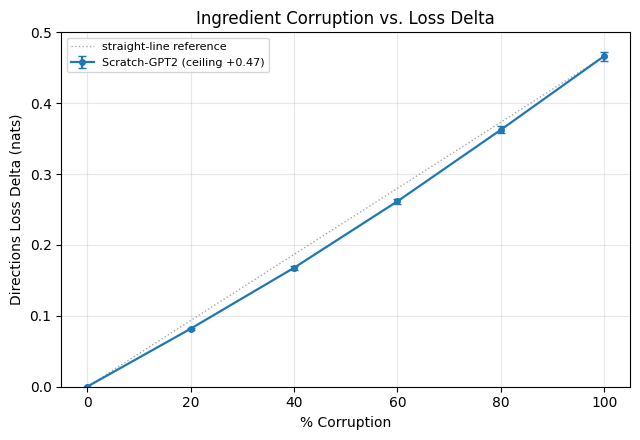

In [12]:
"""
Corrupt the ingredient list one ingredient at a time then calculate the loss.

In theory, if the model is a simple word swapper, then every additional ingredient swapped will linearly
increase the loss since it will only affect its own reference in the directions.

If the model builds coherence and meaning around ingredients, then every additional ingredient swapped will
increase the loss at a rate faster than linear, since there will be word changes outside of the its own
reference in the directions.

Setup is same file for all 3 models, single line comment to switch.

"""

import os
import re
import json
import random
import statistics as st

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from google.colab import drive
from transformers import (
    AutoTokenizer,
    GPT2LMHeadModel,
    PreTrainedModel,
    PretrainedConfig,
)
from transformers.modeling_outputs import CausalLMOutput
from transformers.generation import GenerationMixin

# Important Variables
BASE = "/content/drive/MyDrive/recipe_gpt2"

# Evolve to Key-comment system for different models in this script for even easier diffing
# Can hard code path since after presentation and set on sample size
#MODEL_DIR, MINIMAL, LABEL = f"{BASE}/model_pretrained_250k_ingfirst", False, "Pretrained-FT"
MODEL_DIR, MINIMAL, LABEL = f"{BASE}/model_250k_ingfirst", False, "Scratch-GPT2"
#MODEL_DIR, MINIMAL, LABEL = f"{BASE}/model_minimal_250k_ingfirst", True,  "Scratch-Minimal"

# Test variables
N_RECIPES = 2500
MIN_ING = 5 # only assess on recipes with minimum 5 ingredients, reason: at 2 ingredients, 1 corruption is already half the recipe
LEVELS = [i / 5 for i in range(6)] # Bucket the levels of corruption to match the minimum 5 ingredients
MAX_LENGTH = 512 # Match model setup
SEED = 9

# Units and filler words to ignore when checking if ingredient is used in the directions, try to ignore quatities since not really ingredients
COVERAGE_STOPWORDS = {
    "cup", "cups", "teaspoon", "teaspoons", "tsp", "tablespoon", "tablespoons",
    "tbsp", "ounce", "ounces", "oz", "pound", "pounds", "lb", "lbs", "gram",
    "grams", "g", "kg", "ml", "liter", "large", "small", "medium", "fresh",
    "chopped", "sliced", "diced", "minced", "ground", "package", "can", "cans",
    "and", "or", "of", "to", "the", "a", "for",
}

# Google drive mounting
DRIVE_MOUNT_POINT = "/content/drive"
CACHE_PATH = f"{BASE}/preprocessed_recipes_250k_ingfirst.json" # Locked in training with 250k, so fine to hard code

# Only mount if it isn't already mounted, otherwise Colab complains
if not os.path.ismount(DRIVE_MOUNT_POINT):
    from google.colab import drive
    drive.mount(DRIVE_MOUNT_POINT)


# match the code in the training for minimal config
class MinimalGPTConfig(PretrainedConfig):
    model_type = "minimal_gpt"

    def __init__(self, vocab_size=50257, n_embd=512, n_layer=6, n_head=8,
                 n_inner=2048, ctx=512, **kwargs):
        self.vocab_size = vocab_size
        self.n_embd = n_embd
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_inner = n_inner
        self.ctx = ctx

        self.num_hidden_layers = n_layer
        self.num_attention_heads = n_head
        self.hidden_size = n_embd
        self.max_position_embeddings = ctx
        super().__init__(**kwargs)


class MinimalGPTForCausalLM(PreTrainedModel, GenerationMixin):
    config_class = MinimalGPTConfig

    _tied_weights_keys = []
    all_tied_weights_keys = {}

    def __init__(self, config):
        super().__init__(config)

        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.ctx, config.n_embd)
        layer = nn.TransformerEncoderLayer(
            d_model=config.n_embd,
            nhead=config.n_head,
            dim_feedforward=config.n_inner,
            activation="gelu",
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=config.n_layer)
        self.head = nn.Linear(config.n_embd, config.vocab_size)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        T = input_ids.shape[1]

        pos = torch.arange(T, device=input_ids.device)
        h = self.token_emb(input_ids) + self.pos_emb(pos)

        mask = nn.Transformer.generate_square_subsequent_mask(T).to(input_ids.device)
        h = self.transformer(h, mask=mask)
        logits = self.head(h)

        loss = None
        if labels is not None:
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            loss = nn.functional.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
                ignore_index=-100,
            )
        return CausalLMOutput(loss=loss, logits=logits)

    def prepare_inputs_for_generation(self, input_ids, **kwargs):
        return {"input_ids": input_ids[:, -self.config.ctx:]}


tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = (MinimalGPTForCausalLM if MINIMAL else GPT2LMHeadModel).from_pretrained(MODEL_DIR)
model.eval()

if torch.cuda.is_available():
    model = model.cuda()


@torch.no_grad()
def directions_loss(ing_str, title, directions):
    # We will only score the directions, everything else we will do -100 (padding)
    prompt = f"<|startofrecipe|><|ingredients|>{ing_str}<|title|>{title}<|directions|>"
    p_len = len(tokenizer(prompt).input_ids)

    # if the prompt is longer than the window then skip
    if p_len >= MAX_LENGTH - 8:
        return None

    ids = tokenizer(prompt + directions + "<|endofrecipe|>", truncation=True,max_length=MAX_LENGTH, return_tensors="pt").input_ids.to(model.device)
    labels = ids.clone()
    labels[:, :p_len] = -100

    if int((labels != -100).sum()) == 0:
        return None
    return model(input_ids=ids, labels=labels).loss.item()


def ing_word(ingredient):
    # The "ingredient" is actually longest string of consecutive words which is not a stopword
    # Stops quantities from from causing extra noise
    # This allows stuff like:
    # "boneless skinless chicken breasts" as the ingredient
    # "2 tablespoons unsalted butter" -> "unsalted butter" as the ingredient
    best = cur = []
    for w in re.findall(r"[a-z]+", ingredient.lower()):
        cur = cur + [w] if (len(w) >= 4 and w not in COVERAGE_STOPWORDS) else []
        if len(cur) > len(best):
            best = cur
    return " ".join(best) if best else None


def swap_food(ingredient, new_food):
    # Swap the true ingredient leaving the quantifier to reduce noise from the quantifier
    # "2 tablespoons unsalted butter" -> "2 tablespoons chicken"
    old = ing_word(ingredient)
    if old is None:
        return ingredient
    return re.sub(re.escape(old), new_food, ingredient, count=1, flags=re.I)


def parse(r):
    # Parse the schema for valid recipes for this specific test
    try:
        ing = re.search(r"<\|ingredients\|>(.*?)<\|title\|>", r).group(1)
        ttl = re.search(r"<\|title\|>(.*?)<\|directions\|>", r).group(1)
        dirs = re.search(r"<\|directions\|>(.*?)<\|endofrecipe\|>", r).group(1)
    except AttributeError:
        return None

    ing = [i.strip() for i in ing.split(",") if i.strip()]
    return (ing, ttl, dirs) if len(ing) >= MIN_ING and dirs else None


# Dataloading
recipes = json.load(open(CACHE_PATH))
random.Random(SEED).shuffle(recipes)

eval_set = recipes[int(len(recipes) * 0.95):]
parsed = [p for p in (parse(r) for r in eval_set[:N_RECIPES * 3]) if p][:N_RECIPES] # Grab 3x the necessary recipes incase they don't meet the criteria
print(f"testing {len(parsed)} recipes...")

# Master list of food words to draw replacements from, built from every recipe we are scoring, sort uniq
MASTER = sorted({f for ing, _, _ in parsed for i in ing if (f := ing_word(i))})
print(f"master list has {len(MASTER)} unique ingredients")

# Loop for scoring
rng = random.Random(SEED + 1)
rows, bases = [], []

for idx, (ing, ttl, dirs) in enumerate(parsed):

    # Find the baseline loss of this specific recipe before any corruption
    base = directions_loss(", ".join(ing), ttl, dirs)
    if base is None:
        continue

    # Randomize the corruption position amongst the ingredients list
    order = rng.sample(range(len(ing)), len(ing))
    originals = {ing_word(i) for i in ing}
    replacements = []
    for _ in ing:
        pick = rng.choice(MASTER)
        while pick in originals: # don't "corrupt" with an existing ingredient
            pick = rng.choice(MASTER)
        replacements.append(pick)

    row = []
    for frac in LEVELS:
        # Successively corrupt first k positions of the shuffled order and find the loss after each cumulative corruption
        k = round(frac * len(ing))
        mixed = list(ing)
        for pos in order[:k]:
            mixed[pos] = swap_food(mixed[pos], replacements[pos])
        L = directions_loss(", ".join(mixed), ttl, dirs)
        row.append(None if L is None else L - base) # The effect of corruption is determined relative to the uncorrupted recipe

    if all(v is not None for v in row):
        rows.append(row)
        bases.append(base)

    if (idx + 1) % 100 == 0:
        print(f"{idx + 1}/{len(parsed)}")

# Results
n = len(rows)
means = [st.mean(c) for c in zip(*rows)]
sems = [st.pstdev(c) / n ** 0.5 for c in zip(*rows)] # error bars for the plot
ceiling, base_mean = means[-1], st.mean(bases)

print(f"\n{LABEL}: n={n}, baseline loss {base_mean:.3f}")
print(f"{'corrupted':>10}{'mean delta':>13}{'increment':>11}")
for i, (f, m) in enumerate(zip(LEVELS, means)):
    inc = "" if i == 0 else f"{m - means[i-1]:+.4f}"
    print(f"{f*100:>9.0f}%{m:>+13.4f}{inc:>11}")

# Ceiling is how much the model cares about the ingredients at all since the entire ingredients list is incorrect
print(f"\nceiling {ceiling:+.4f} ({ceiling/base_mean*100:.1f}% of baseline)")

# Start plotting figures
x = [v * 100 for v in LEVELS]
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(x, means, yerr=sems, marker="o", ms=4, capsize=3, lw=1.6, label=f"{LABEL} (ceiling {ceiling:+.2f})")
plt.plot([0, 100], [0, ceiling], ls=":", lw=1, c="gray", alpha=0.7, label="straight-line reference")
plt.xlabel("% Corruption")
plt.ylabel("Directions Loss Delta (nats)")
plt.title(f"Ingredient Corruption vs. Loss Delta")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.ylim(0.0,0.5)
plt.tight_layout()
plt.show()
plt.close()